In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv")

#전체 변수 상관관계 히트맵 (Heatmap)

=== 1. 상관관계 히트맵 시각화를 시작합니다 ===


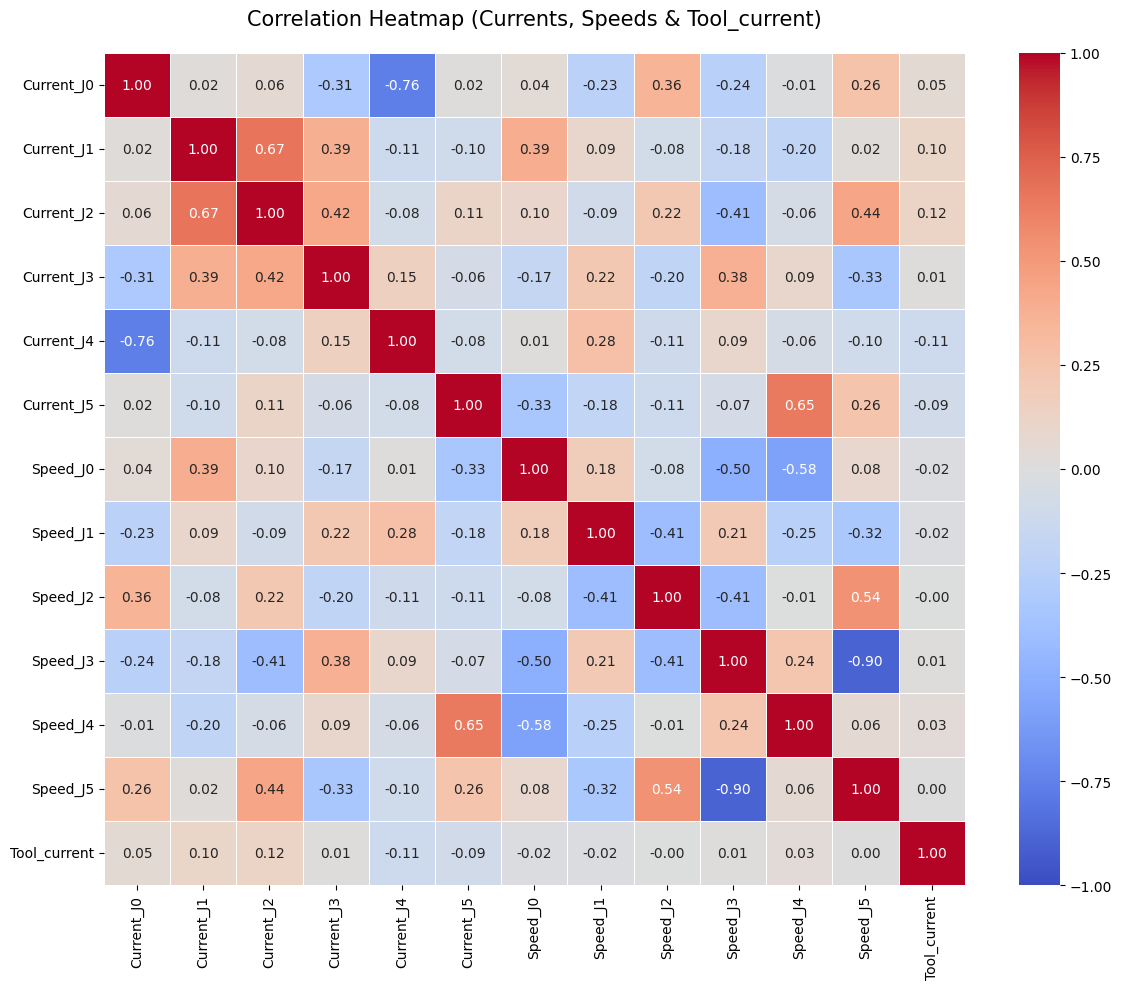

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# [전처리] 1. 결측치(54개 행)가 포함된 행 전원 드롭 (7,409행 -> 7,355행으로 정제)
df_clean = df.dropna()

# [전처리] 2. 분석에 사용할 센서 변수 정의 (전류 6개, 속도 6개, 타겟 1개)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
target_col = 'Tool_current'

# 전체 시각화 및 분석용 데이터 프레임 슬라이싱 (총 13개 컬럼)
analysis_df = df_clean[current_cols + speed_cols + [target_col]]

print("=== 1. 상관관계 히트맵 시각화를 시작합니다 ===")
plt.figure(figsize=(12, 10))

# 상관계수 행렬 계산
corr_matrix = analysis_df.corr()

# 히트맵 그리기
sns.heatmap(
    corr_matrix,
    annot=True,          # 각 칸에 숫자 표시
    cmap='coolwarm',     # 파란색(음의 상관관계) ~ 빨간색(양의 상관관계) 컬러맵
    fmt=".2f",           # 소수점 둘째 자리까지 표시
    linewidths=0.5,      # 칸 사이 경계선 두께
    vmin=-1, vmax=1      # 상관계수 최소/최대값 제한
)

plt.title("Correlation Heatmap (Currents, Speeds & Tool_current)", fontsize=15, pad=20)
plt.tight_layout()
plt.show()

#독립변수들의 VIF 다중공선성 계산 (VIF Table)


=== 2. 독립변수 간 다중공선성(VIF)을 계산합니다 ===

[VIF 계산 결과 (높은 순서)]
       Feature         VIF
0     Speed_J3  144.287432
1     Speed_J5  113.157685
2     Speed_J0   24.013346
3   Current_J2   22.135950
4   Current_J1   15.595237
5   Current_J3    6.382776
6   Current_J0    3.200290
7     Speed_J4    3.183987
8   Current_J4    2.786957
9     Speed_J2    2.460194
10  Current_J5    2.308267
11    Speed_J1    1.661301


/tmp/ipykernel_463/602998747.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_df_sorted, x="VIF", y="Feature", palette="viridis")


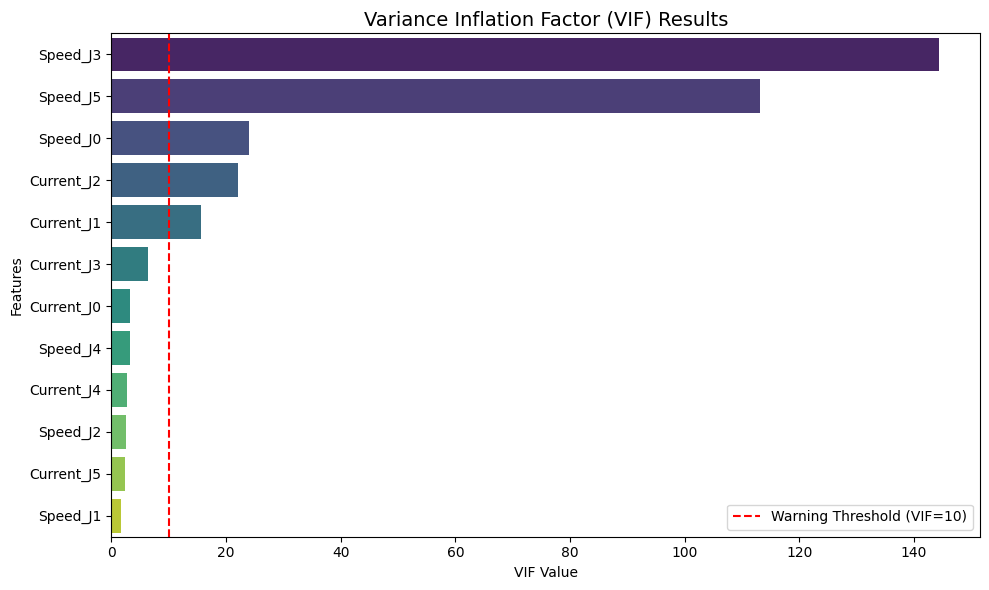

In [4]:
print("\n=== 2. 독립변수 간 다중공선성(VIF)을 계산합니다 ===")

# VIF 계산을 위한 독립변수(X) 설정 (타겟 변수인 Tool_current는 제외)
X_features = analysis_df[current_cols + speed_cols]

# VIF 데이터프레임 생성
vif_df = pd.DataFrame()
vif_df["Feature"] = X_features.columns
vif_df["VIF"] = [variance_inflation_factor(X_features.values, i) for i in range(X_features.shape[1])]

# VIF 수치가 높은 순서대로 내림차순 정렬하여 출력
vif_df_sorted = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# 결과 출력
print("\n[VIF 계산 결과 (높은 순서)]")
print(vif_df_sorted)

# VIF 해석을 돕기 위한 간단한 시각화 (바 차트)
plt.figure(figsize=(10, 6))
sns.barplot(data=vif_df_sorted, x="VIF", y="Feature", palette="viridis")
plt.axvline(x=10, color='r', linestyle='--', label='Warning Threshold (VIF=10)')
plt.title("Variance Inflation Factor (VIF) Results", fontsize=14)
plt.xlabel("VIF Value")
plt.ylabel("Features")
plt.legend()
plt.tight_layout()
plt.show()

#타겟 변수(Tool_current)의 분포 시각화

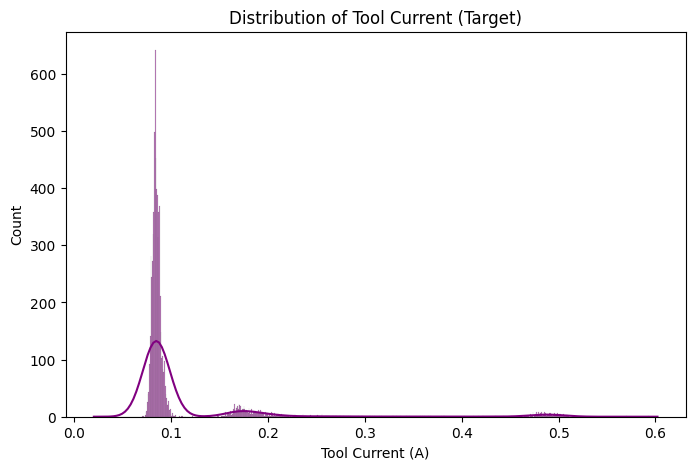

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Tool_current'], kde=True, color='purple')
plt.title("Distribution of Tool Current (Target)")
plt.xlabel("Tool Current (A)")
plt.show()

#비선형 관계 확인을 위한 산점도 (Scatter Plot)

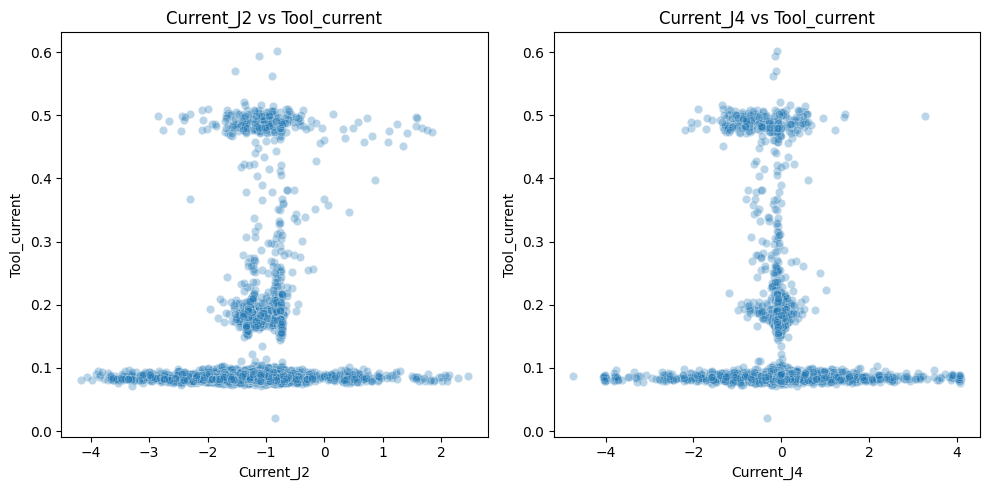

In [6]:
plt.figure(figsize=(10, 5))
# 2번 관절 전류 vs 툴 전류
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x='Current_J2', y='Tool_current', alpha=0.3)
plt.title("Current_J2 vs Tool_current")

# 4번 관절 전류 vs 툴 전류
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='Current_J4', y='Tool_current', alpha=0.3)
plt.title("Current_J4 vs Tool_current")

plt.tight_layout()
plt.show()

#타겟과 상관관계가 높았던 핵심 변수들 간의 페어플롯 (Pairplot)

=== 4. 핵심 변수 간의 페어플롯(Pairplot) 시각화를 시작합니다 ===


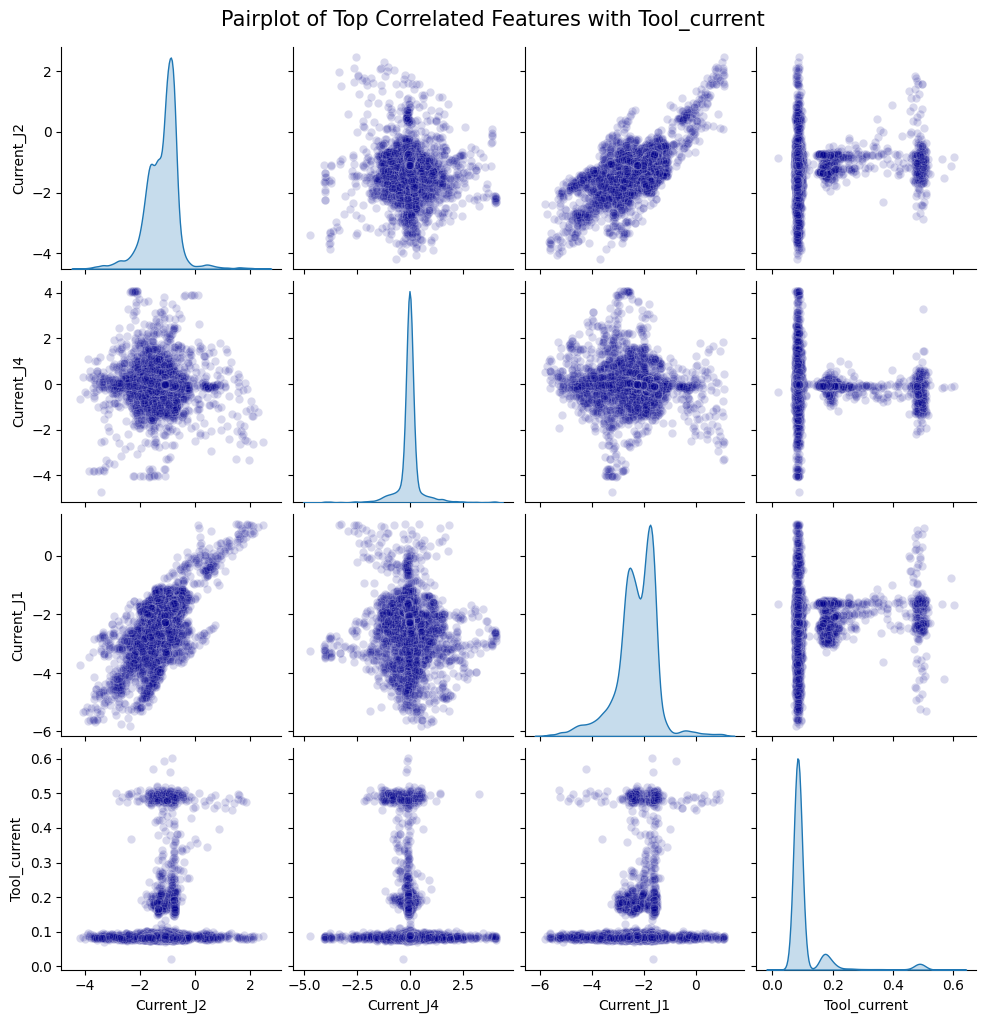

In [7]:
print("=== 4. 핵심 변수 간의 페어플롯(Pairplot) 시각화를 시작합니다 ===")

# 타겟과 상관관계가 비교적 높았던 대표 변수들 선택
selected_cols = ['Current_J2', 'Current_J4', 'Current_J1', 'Tool_current']

# 페어플롯 생성
# diag_kind='kde'로 대각선에는 해당 변수의 분포도를 그리고, 산점도 투명도(alpha)를 조절해 밀집도를 봅니다.
g = sns.pairplot(
    df_clean[selected_cols],
    diag_kind='kde',
    plot_kws={'alpha': 0.15, 'color': 'darkblue'}
)
g.fig.suptitle("Pairplot of Top Correlated Features with Tool_current", y=1.02, fontsize=15)
plt.show()

#주요 관절별 [속도 vs 전류] 물리적 관계 시각화 (Joint-by-Joint)


=== 5. 관절별 '속도(Speed) vs 전류(Current)'의 물리적 산점도 시각화를 시작합니다 ===


/tmp/ipykernel_463/4268371381.py:26: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_463/4268371381.py:26: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


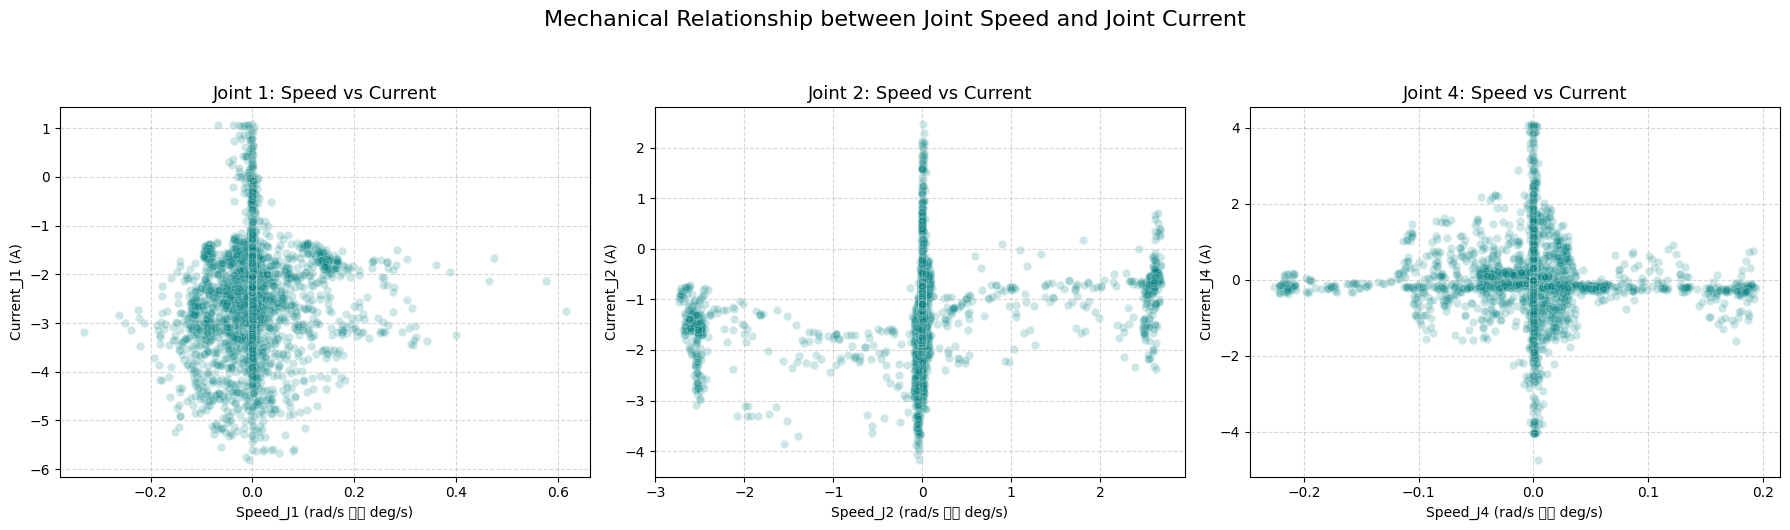

In [8]:
print("\n=== 5. 관절별 '속도(Speed) vs 전류(Current)'의 물리적 산점도 시각화를 시작합니다 ===")

# 로봇에서 가장 힘을 많이 쓰는 핵심 관절 3개 선택 (J1: 어깨, J2: 팔꿈치, J4: 손목)
joints_to_plot = [1, 2, 4]

plt.figure(figsize=(18, 5))

for idx, j in enumerate(joints_to_plot):
    plt.subplot(1, 3, idx+1)

    # x축은 속도, y축은 전류로 설정하여 산점도를 그립니다.
    sns.scatterplot(
        data=df_clean,
        x=f'Speed_J{j}',
        y=f'Current_J{j}',
        alpha=0.2,
        color='teal'
    )

    plt.title(f"Joint {j}: Speed vs Current", fontsize=13)
    plt.xlabel(f"Speed_J{j} (rad/s 또는 deg/s)")
    plt.ylabel(f"Current_J{j} (A)")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Mechanical Relationship between Joint Speed and Joint Current", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

#단일 작동 사이클 내 시계열 변화 시각화 (Time-Series Profile)

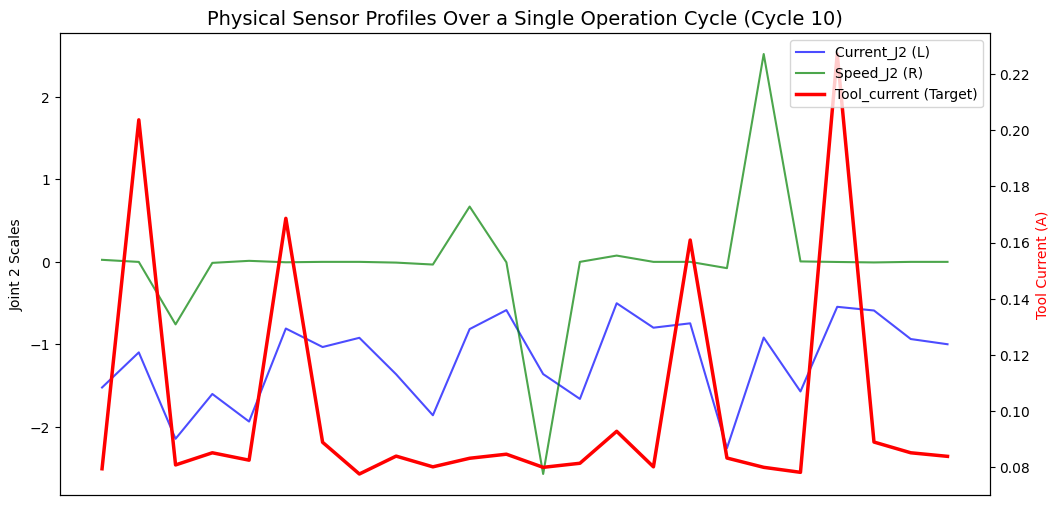

In [9]:
# cycle 10번 데이터만 추출 (시간 흐름에 따른 변화 추적)
cycle_data = df_clean[df_clean['cycle '] == 10].sort_values(by='Timestamp')

fig, ax1 = plt.subplots(figsize=(12, 6))

# 첫 번째 Y축: 관절 속도 및 전류
ax1.plot(cycle_data['Timestamp'].astype(str), cycle_data['Current_J2'], label='Current_J2 (L)', color='blue', alpha=0.7)
ax1.plot(cycle_data['Timestamp'].astype(str), cycle_data['Speed_J2'], label='Speed_J2 (R)', color='green', alpha=0.7)
ax1.set_ylabel('Joint 2 Scales', color='black')

# 두 번째 Y축: 그리퍼 전류 (Target)
ax2 = ax1.twinx()
ax2.plot(cycle_data['Timestamp'].astype(str), cycle_data['Tool_current'], label='Tool_current (Target)', color='red', linewidth=2.5)
ax2.set_ylabel('Tool Current (A)', color='red')

plt.title("Physical Sensor Profiles Over a Single Operation Cycle (Cycle 10)", fontsize=14)
plt.xticks([]) # 시간 레이블이 겹치므로 생략
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

#사이클별 분석

=== 1. 모든 사이클의 요약 통계를 생성합니다 ===

[사이클별 요약 통계 (상위 15개 사이클)]
    cycle   Duration_Steps  Max_Tool_Current  Max_Speed_J2  Min_Current_J2  \
0        1              39          0.505895      2.594071       -3.577167   
1        2              46          0.305517      2.545263       -1.850517   
2        3              26          0.190770      1.208486       -2.176832   
3        4              24          0.501990      2.655249       -3.657895   
4        5              27          0.481879      2.598885       -2.097569   
5        6              39          0.473561      2.547778       -1.864321   
6        7              25          0.501310      2.634015       -2.194359   
7        8              24          0.491298      2.616601       -3.526919   
8        9              24          0.497577      2.545139       -2.265597   
9       10              24          0.227095      2.517866       -2.256607   
10      11              25          0.509628      2.287595       -3.300768   
11   

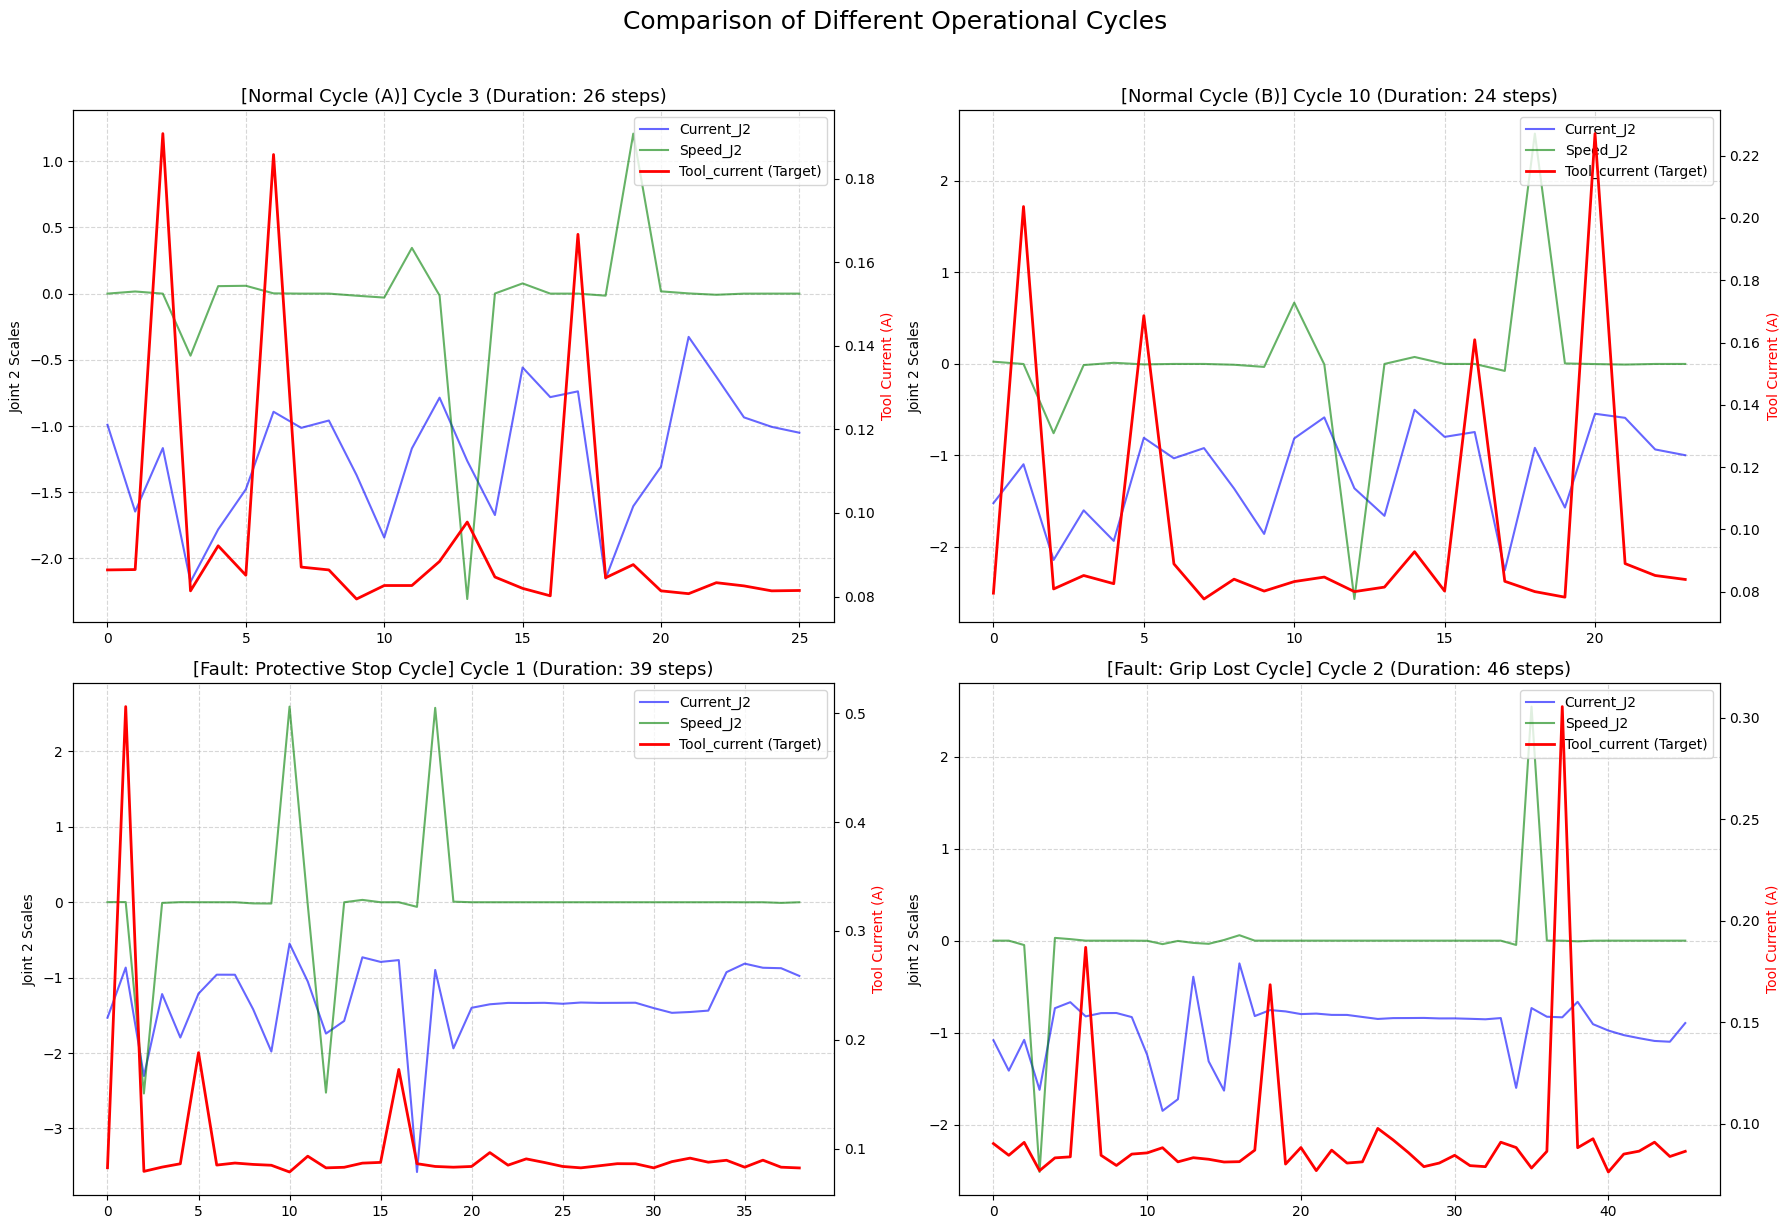

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df_clean 데이터프레임이 준비된 상태에서 실행합니다.

# ==========================================
# [분석 1] 모든 사이클별 핵심 통계 및 고장 여부 요약표 생성
# ==========================================
print("=== 1. 모든 사이클의 요약 통계를 생성합니다 ===")

cycle_summary = df_clean.groupby('cycle ').agg(
    Duration_Steps=('Timestamp', 'count'),            # 사이클당 동작 시간(스텝 수)
    Max_Tool_Current=('Tool_current', 'max'),         # 그리퍼 최대 전류
    Max_Speed_J2=('Speed_J2', 'max'),                 # 2번 관절 최대 속도
    Min_Current_J2=('Current_J2', 'min'),             # 2번 관절 최대 부하 (음수 최댓값)
    Protective_Stop_Occurred=('Robot_ProtectiveStop', lambda x: 'True' in x.astype(str).values), # 보호 정지 발생 여부
    Grip_Lost_Occurred=('grip_lost', lambda x: True in x.values)                                 # 그립 유실 발생 여부
).reset_index()

# 샘플로 상위 15개 사이클 통계 출력
print("\n[사이클별 요약 통계 (상위 15개 사이클)]")
print(cycle_summary.head(15))


# ==========================================
# [분석 2] 서로 다른 유형의 사이클 4개 자동 추출 및 비교 시각화
# ==========================================
print("\n=== 2. 성격이 다른 대표 사이클 4개를 추출하여 비교 시각화합니다 ===")

# 유형별 사이클 매칭
# 1. 아무 고장도 없는 평화로운 정상 사이클 중 하나 (예: 첫 번째 정상 사이클)
normal_cycles = cycle_summary[(cycle_summary['Protective_Stop_Occurred'] == False) & (cycle_summary['Grip_Lost_Occurred'] == False)]['cycle '].values
normal_cycle_id = normal_cycles[0] if len(normal_cycles) > 0 else 1

# 2. 보호 정지(Protective Stop)가 발생한 사이클 중 하나
p_stop_cycles = cycle_summary[cycle_summary['Protective_Stop_Occurred'] == True]['cycle '].values
p_stop_cycle_id = p_stop_cycles[0] if len(p_stop_cycles) > 0 else None

# 3. 그립 유실(Grip Lost)이 발생한 사이클 중 하나
grip_lost_cycles = cycle_summary[cycle_summary['Grip_Lost_Occurred'] == True]['cycle '].values
grip_lost_cycle_id = grip_lost_cycles[0] if len(grip_lost_cycles) > 0 else None

# 4. 비교 분석을 위한 또 다른 정상 사이클 (속도가 빠르거나 하중이 다른 정상군)
another_normal_id = normal_cycles[5] if len(normal_cycles) > 5 else normal_cycles[-1]

# 그릴 사이클 리스트 구성
compare_cycles = [normal_cycle_id, another_normal_id, p_stop_cycle_id, grip_lost_cycle_id]
compare_titles = ["Normal Cycle (A)", "Normal Cycle (B)", "Fault: Protective Stop Cycle", "Fault: Grip Lost Cycle"]

# $2 \times 2$ 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, c_id in enumerate(compare_cycles):
    if c_id is None:
        axes[idx].text(0.5, 0.5, "Corresponding Fault Cycle Not Found", ha='center', va='center', fontsize=14)
        continue

    # 해당 사이클 데이터 필터링
    c_data = df_clean[df_clean['cycle '] == c_id].sort_values(by='Timestamp')

    # 시간축을 위한 인덱스 생성 (x축이 겹치지 않도록 임시 시퀀스 사용)
    time_steps = np.arange(len(c_data))

    # 왼쪽 Y축 (관절 속도 및 전류)
    ax_left = axes[idx]
    ax_left.plot(time_steps, c_data['Current_J2'], label='Current_J2', color='blue', alpha=0.6)
    ax_left.plot(time_steps, c_data['Speed_J2'], label='Speed_J2', color='green', alpha=0.6)
    ax_left.set_ylabel('Joint 2 Scales', color='black')
    ax_left.grid(True, linestyle='--', alpha=0.5)

    # 오른쪽 Y축 (그리퍼 전류 - Target)
    ax_right = ax_left.twinx()
    ax_right.plot(time_steps, c_data['Tool_current'], label='Tool_current (Target)', color='red', linewidth=2)
    ax_right.set_ylabel('Tool Current (A)', color='red')

    # 타이틀 설정
    axes[idx].set_title(f"[{compare_titles[idx]}] Cycle {c_id} (Duration: {len(c_data)} steps)", fontsize=13)

    # 범례 합치기
    lines1, labels1 = ax_left.get_legend_handles_labels()
    lines2, labels2 = ax_right.get_legend_handles_labels()
    ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle("Comparison of Different Operational Cycles", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()